## SAM 3 video segmentation on robot manipulation data

Adapted from `sam3_video_predictor_example.ipynb`. Runs SAM 3 text-prompt segmentation + tracking on robot data under `~/datasets/manipulation_dataset_v0.1/<task>/<episode>/`. Each episode has 4 cameras interleaved in `colors/`. Workflow:

1. Pick a **task** (`chip_pick`, `kit_pick`, `mask_pick`, …) and an **episode**.
2. Stage only the **head camera** frames (`*_color_1.jpg`) into a clean folder of integer-named symlinks.
3. Run text-prompt segmentation on frame 0, then propagate to the full clip.
4. Save per-frame masks as 3-channel RGB PNGs (white = foreground) to `<episode>/mask/` — drop-in as an extra camera for ACT-style policies.

In [15]:
!nvidia-smi

Thu May  7 18:38:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.119.02             Driver Version: 580.119.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5090        Off |   00000000:01:00.0  On |                  N/A |
|  0%   46C    P1             67W /  600W |    8276MiB /  32607MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Imports & build predictor

In [16]:
import copy
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import sam3
import torch
from PIL import Image
from sam3.model_builder import build_sam3_video_predictor
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)

plt.rcParams["axes.titlesize"] = 12
plt.rcParams["figure.titlesize"] = 12


def propagate_in_video(predictor, session_id, start_frame_index=0):
    """Propagate forward+backward from a given frame.

    Passing start_frame_index=0 explicitly is required for the point-prompt
    (instance-tracking) path: that path doesn't populate `previous_stages_out`,
    so without an explicit start the predictor raises
    'No prompts are received on any frames'. Text/box prompts work either way.
    """
    outputs_per_frame = {}
    for response in predictor.handle_stream_request(
        request=dict(
            type="propagate_in_video",
            session_id=session_id,
            start_frame_index=start_frame_index,
        )
    ):
        outputs_per_frame[response["frame_index"]] = response["outputs"]
    return outputs_per_frame

In [17]:
gpus_to_use = list(range(torch.cuda.device_count()))
predictor = build_sam3_video_predictor(gpus_to_use=gpus_to_use)

INFO 2026-05-07 18:38:08,992 468172 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-05-07 18:38:08,993 468172 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-05-07 18:38:08,993 468172 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-05-07 18:38:11,524 468172 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-05-07 18:38:13,602 468172 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-05-07 18:38:13,603 468172 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




### Pick a task and episode

Edit `TASK` and `EPISODE` below. The dataset root holds one directory per task (e.g. `chip_pick`, `kit_pick`, `mask_pick`); each task contains episodes.

In [18]:
DATASET_ROOT = os.path.expanduser("~/datasets/manipulation_dataset_v0.1")
HEAD_CAM_SUFFIX = "_color_1.jpg"  # the head camera

# --- Pick a task ---
tasks = sorted(
    d for d in os.listdir(DATASET_ROOT)
    if os.path.isdir(os.path.join(DATASET_ROOT, d))
)
print(f"Available tasks: {tasks}")

TASK = "mask_pick"          # <-- edit me  (e.g. chip_pick, kit_pick, mask_pick)

task_dir = os.path.join(DATASET_ROOT, TASK)
assert os.path.isdir(task_dir), f"missing task dir: {task_dir}"

# --- Pick an episode within that task ---
episodes = sorted(
    d for d in os.listdir(task_dir)
    if d.startswith("episode_") and os.path.isdir(os.path.join(task_dir, d))
)
print(f"Episodes in {TASK} ({len(episodes)}): {episodes[0]} ... {episodes[-1]}")

EPISODE = "episode_0001"   # <-- edit me

episode_dir = os.path.join(task_dir, EPISODE)
colors_dir  = os.path.join(episode_dir, "colors")
assert os.path.isdir(colors_dir), f"missing {colors_dir}"
print(f"Selected: {episode_dir}")

Available tasks: ['chip_pick', 'kit_pick', 'mask_pick']
Episodes in mask_pick (53): episode_0000 ... episode_0052
Selected: /home/santari/datasets/manipulation_dataset_v0.1/mask_pick/episode_0001


### Stage head-cam frames

Builds a clean directory of symlinks named `00000.jpg, 00001.jpg, ...` pointing at the head-cam frames in `colors/`. SAM 3's video loader expects integer-named files, and we don't want it picking up the other 3 cameras. Re-running this cell is safe (idempotent).

In [19]:
stage_dir = os.path.join(episode_dir, "head_cam_frames")
os.makedirs(stage_dir, exist_ok=True)

head_frames_src = sorted(glob.glob(os.path.join(colors_dir, f"*{HEAD_CAM_SUFFIX}")))
assert head_frames_src, f"no *{HEAD_CAM_SUFFIX} files in {colors_dir}"

# clear any stale entries from a previous run
for old in glob.glob(os.path.join(stage_dir, "*.jpg")):
    if os.path.islink(old) or os.path.isfile(old):
        os.unlink(old)

for i, src in enumerate(head_frames_src):
    link = os.path.join(stage_dir, f"{i:05d}.jpg")
    os.symlink(os.path.abspath(src), link)

print(f"Staged {len(head_frames_src)} head-cam frames at {stage_dir}")
print(f"  first src: {os.path.basename(head_frames_src[0])}  ->  00000.jpg")
print(f"  last  src: {os.path.basename(head_frames_src[-1])}  ->  {len(head_frames_src)-1:05d}.jpg")

# Frames used for visualization (helpers accept paths). Keep originals so we can
# also reference the source filename if desired.
video_frames_for_vis = head_frames_src

Staged 164 head-cam frames at /home/santari/datasets/manipulation_dataset_v0.1/mask_pick/episode_0001/head_cam_frames
  first src: 000000_color_1.jpg  ->  00000.jpg
  last  src: 000163_color_1.jpg  ->  00163.jpg


### Open inference session

In [20]:
response = predictor.handle_request(
    request=dict(type="start_session", resource_path=stage_dir)
)
session_id = response["session_id"]
print(f"session_id = {session_id}")

frame loading (image folder) [rank=0]: 100%|██████████| 164/164 [00:01<00:00, 155.74it/s]
INFO 2026-05-07 18:38:31,676 468172 sam3_base_predictor.py: 146: started new session 8f8d69c2-2bc6-4b3a-81b2-2b50b06bdd96


session_id = 8f8d69c2-2bc6-4b3a-81b2-2b50b06bdd96


### Text prompt on frame 0

Edit `TEXT_PROMPT` below. If you switch prompts, run the reset cell first or the result will mix prompts.

In [21]:
# Run this cell only when changing the text prompt mid-session.
_ = predictor.handle_request(
    request=dict(type="reset_session", session_id=session_id)
)

frame 0: detected 1 object(s), ids=[0]


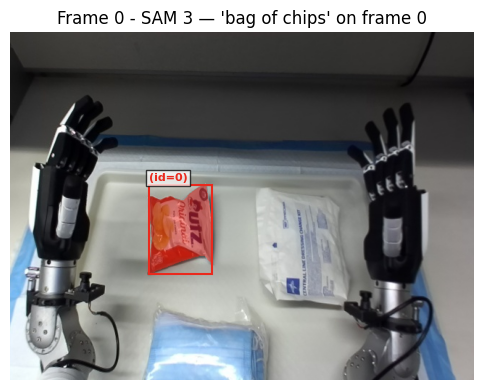

In [8]:
TEXT_PROMPT = "bag of chips"   # <-- edit me
frame_idx = 0

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=frame_idx,
        text=TEXT_PROMPT,
    )
)
out = response["outputs"]
print(f"frame 0: detected {len(out['out_obj_ids'])} object(s), ids={list(out['out_obj_ids'])}")

plt.close("all")
visualize_formatted_frame_output(
    frame_idx,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({frame_idx: out})],
    titles=[f"SAM 3 — '{TEXT_PROMPT}' on frame 0"],
    figsize=(6, 4),
)

### Alternative: box prompt (when text fails)

When text doesn't latch onto an object (e.g., visually generic packets in the surgical scenes), use a bounding box on frame 0 instead. **Run only one of Text-prompt OR Box-prompt per session.** If switching, run the reset cell (above) first so SAM 3 doesn't mix old + new prompts.

The cell below opens an interactive matplotlib window — drag a rectangle around the target. Requires `ipympl` (`pip install ipympl`) for `%matplotlib widget`. If that's unavailable, just set `BOX_XYXY = (x0, y0, x1, y1)` manually in the next cell.

In [ ]:
%matplotlib widget
from matplotlib.widgets import RectangleSelector

frame0 = np.array(Image.open(head_frames_src[0]))
H_img, W_img = frame0.shape[:2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(frame0)
ax.set_title("Drag a rectangle around the target. Coords print on release.")

BOX_XYXY = None  # populated by the selector callback

def _on_select(eclick, erelease):
    global BOX_XYXY
    x0 = int(min(eclick.xdata, erelease.xdata))
    y0 = int(min(eclick.ydata, erelease.ydata))
    x1 = int(max(eclick.xdata, erelease.xdata))
    y1 = int(max(eclick.ydata, erelease.ydata))
    BOX_XYXY = (x0, y0, x1, y1)
    print(f"BOX_XYXY = {BOX_XYXY}   (image is {W_img}x{H_img})")

_selector = RectangleSelector(
    ax, _on_select,
    useblit=True, button=[1], minspanx=5, minspany=5,
    spancoords="pixels", interactive=True,
)
plt.show()

# Manual fallback if %matplotlib widget isn't available:
# BOX_XYXY = (x_min, y_min, x_max, y_max)

In [ ]:
%matplotlib inline
assert BOX_XYXY is not None, "Draw a box in the cell above, or set BOX_XYXY manually"

x0, y0, x1, y1 = BOX_XYXY
# SAM 3 expects normalized xywh (x_min, y_min, w, h) when rel_coordinates=True (default)
box_xywh = torch.tensor(
    [[x0 / W_img, y0 / H_img, (x1 - x0) / W_img, (y1 - y0) / H_img]],
    dtype=torch.float32,
)
box_labels = torch.tensor([1], dtype=torch.int64)  # 1 = positive box

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=0,
        bounding_boxes=box_xywh,
        bounding_box_labels=box_labels,
    )
)
out = response["outputs"]
print(f"frame 0: detected {len(out['out_obj_ids'])} object(s), ids={list(out['out_obj_ids'])}")

plt.close("all")
visualize_formatted_frame_output(
    0,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({0: out})],
    titles=["SAM 3 \u2014 box prompt on frame 0"],
    figsize=(6, 4),
)

### Alternative: point prompt (track ONE specific instance)

SAM 3 box and text prompts are *concept-based* — propagation re-detects similar things on every frame and can drop the track when confidence dips. **Point prompts with an `obj_id`** are SAM 2-style *instance* tracking: you click on the specific object, SAM 3 just follows that one instance forward. Best fit when you want one particular packet/kit and don't care about "all things that look like it."

Run the reset cell first if you previously sent a text or box prompt (point prompts are mutually exclusive with those in a session).

**Left-click** = positive point (on the target). **Right-click** = negative point (push the mask away from this spot, e.g., onto background). Usually one positive click is enough.

In [ ]:
%matplotlib widget

frame0 = np.array(Image.open(head_frames_src[0]))
H_img, W_img = frame0.shape[:2]

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(frame0)
ax.set_title("Left-click = positive  |  Right-click = negative.  Then run the next cell.")

POINTS_PIXEL = []   # list of (x, y, label)

def _on_click(event):
    if event.inaxes != ax:
        return
    x, y = int(event.xdata), int(event.ydata)
    if event.button == 1:        # left = positive
        POINTS_PIXEL.append((x, y, 1))
        ax.plot(x, y, marker="*", color="lime", markersize=18, markeredgecolor="black")
    elif event.button == 3:      # right = negative
        POINTS_PIXEL.append((x, y, 0))
        ax.plot(x, y, marker="X", color="red", markersize=14, markeredgecolor="black")
    else:
        return
    fig.canvas.draw_idle()
    print(f"POINTS_PIXEL ({len(POINTS_PIXEL)}): {POINTS_PIXEL}")

_cid = fig.canvas.mpl_connect("button_press_event", _on_click)
plt.show()

In [ ]:
%matplotlib inline
assert POINTS_PIXEL, "Click at least one positive point in the cell above"

OBJ_ID = 1   # single instance to track; change if you want a different id

xs_rel = [x / W_img for (x, _, _) in POINTS_PIXEL]
ys_rel = [y / H_img for (_, y, _) in POINTS_PIXEL]
labels = [lab    for (_, _, lab) in POINTS_PIXEL]

points = torch.tensor(list(zip(xs_rel, ys_rel)), dtype=torch.float32)
point_labels = torch.tensor(labels, dtype=torch.int32)

response = predictor.handle_request(
    request=dict(
        type="add_prompt",
        session_id=session_id,
        frame_index=0,
        points=points,
        point_labels=point_labels,
        obj_id=OBJ_ID,
    )
)
out = response["outputs"]
print(f"frame 0: detected {len(out['out_obj_ids'])} object(s), ids={list(out['out_obj_ids'])}")

plt.close("all")
visualize_formatted_frame_output(
    0,
    video_frames_for_vis,
    outputs_list=[prepare_masks_for_visualization({0: out})],
    titles=["SAM 3 \u2014 point prompt on frame 0 (instance tracking)"],
    figsize=(6, 4),
)

### Propagate to full video

propagate_in_video:   0%|          | 0/213 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

INFO 2026-05-07 15:01:32,823 337563 sam3_base_predictor.py: 305: propagation ended in session 5cc99d6a-685c-4421-8c32-ba4287617fe3


propagated through 213 frames


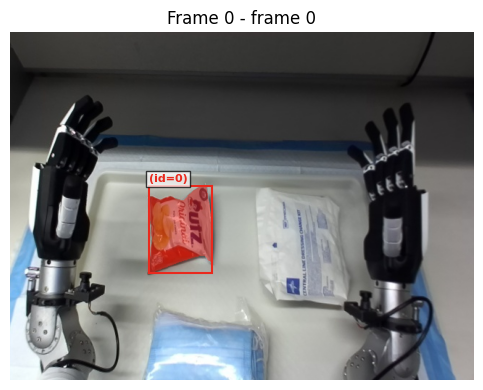

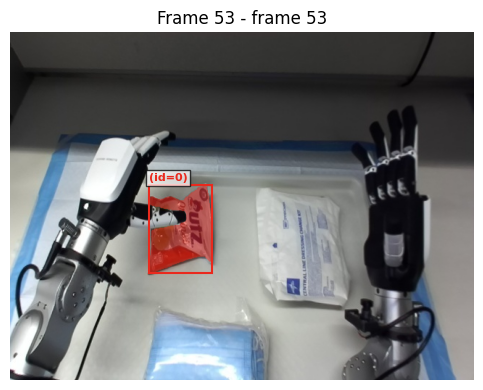

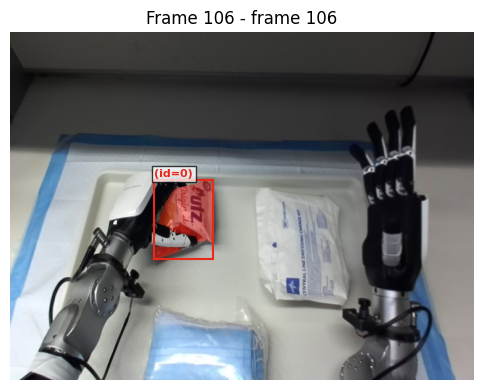

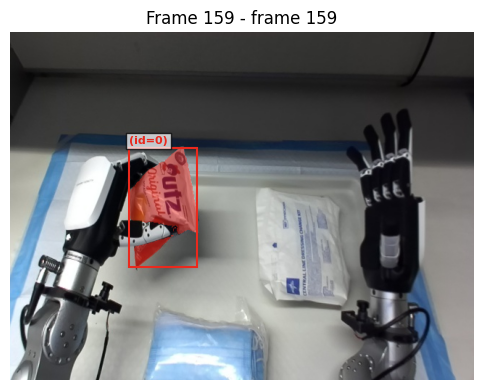

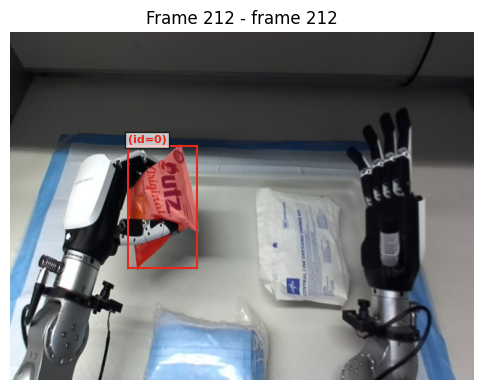

In [9]:
outputs_per_frame_raw = propagate_in_video(predictor, session_id)
print(f"propagated through {len(outputs_per_frame_raw)} frames")

# IMPORTANT: prepare_masks_for_visualization mutates the dict it's given.
# Pass a deep copy so outputs_per_frame_raw stays usable for the save cell below.
import copy
outputs_per_frame_vis = prepare_masks_for_visualization(copy.deepcopy(outputs_per_frame_raw))

vis_frame_stride = max(1, len(outputs_per_frame_vis) // 4)
plt.close("all")
for i in range(0, len(outputs_per_frame_vis), vis_frame_stride):
    visualize_formatted_frame_output(
        i,
        video_frames_for_vis,
        outputs_list=[outputs_per_frame_vis],
        titles=[f"frame {i}"],
        figsize=(6, 4),
    )

### Save masks (3-channel RGB, white = foreground)

One PNG per head-cam frame at `<episode>/mask/<index>.png`. Same resolution as the head-cam JPEGs, RGB `uint8`, `(0,0,0)`=background, `(255,255,255)`=foreground. Drop-in as an extra camera for ACT-style policies.

In [10]:
# ACT-friendly mask format: one 3-channel uint8 RGB PNG per frame, at the head-cam JPEG
# resolution. (0,0,0)=background, (255,255,255)=foreground (union of all detected objects).
# This makes mask/ a drop-in "extra camera" for ACT/LeRobot pipelines with no loader surgery.

mask_dir = os.path.join(episode_dir, "mask")
os.makedirs(mask_dir, exist_ok=True)

# Match head-cam JPEG resolution (PIL gives (W, H))
with Image.open(head_frames_src[0]) as _im:
    target_w, target_h = _im.size

# SAM 3's native mask size — only used to allocate the empty canvas when a frame has no detections
any_out = next(iter(outputs_per_frame_raw.values()))
Hm, Wm = any_out["out_binary_masks"].shape[-2:]

n_saved = 0
n_with_fg = 0
for fidx in range(len(head_frames_src)):
    fg = np.zeros((Hm, Wm), dtype=bool)
    out = outputs_per_frame_raw.get(fidx)
    if out is not None:
        bin_masks = np.asarray(out["out_binary_masks"])  # (N, Hm, Wm) bool
        if bin_masks.size:
            fg = np.any(bin_masks, axis=0)  # union over all detected objects

    # 0/255 grayscale -> resize NEAREST to head-cam res -> broadcast to RGB
    gray = Image.fromarray((fg.astype(np.uint8) * 255), mode="L").resize(
        (target_w, target_h), resample=Image.NEAREST
    )
    rgb = Image.merge("RGB", (gray, gray, gray))
    rgb.save(os.path.join(mask_dir, f"{fidx:05d}_mask.png"))
    n_saved += 1
    if fg.any():
        n_with_fg += 1

print(f"Saved {n_saved} masks @ {target_w}x{target_h} RGB (white=fg, black=bg) -> {mask_dir}")
print(f"  frames with non-empty foreground: {n_with_fg}/{n_saved}")

Saved 213 masks @ 640x480 RGB (white=fg, black=bg) -> /home/santari/datasets/data_v0.1/data/chip_pick/episode_0001/mask
  frames with non-empty foreground: 213/213


### Cleanup

In [11]:
_ = predictor.handle_request(
    request=dict(type="close_session", session_id=session_id)
)

INFO 2026-05-07 15:01:35,666 337563 sam3_base_predictor.py: 345: removed session 5cc99d6a-685c-4421-8c32-ba4287617fe3


In [12]:
predictor.shutdown()